In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
dtype = torch.float32
L = 1
dim = 2
nx = 32
dx = L/nx

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros_like(domain.min)
domain.max = torch.ones_like(domain.max) * L

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.1, 128, shiftScheme = 'delta') 
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

particles = particles._replace(positions = particles.positions - dx/2)
particlesLR = particlesLR._replace(positions = particlesLR.positions - dx/4)    

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

particleState = wcstateToState(particles)


  0%|          | 0/128 [00:00<?, ?it/s]

0it [00:00, ?it/s]

In [3]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import numpy as np
import jax
import exponax as ex
import matplotlib.pyplot as plt
import h5py

NUM_POINTS = nx

datafile = h5py.File(f"data_diffusedNoise_nx_{nx}.h5", "r")

u0 = np.array(datafile['u_0'])
jacobian = np.array(datafile['d'])
hessian = np.array(datafile['d2'])
patrician = np.array(datafile['d3'])

selected_seed = 0

values = [u0[selected_seed], jacobian[selected_seed], hessian[selected_seed], patrician[selected_seed]]
values = [torch.tensor(v, device=device, dtype=dtype).flatten(-2).T for v in values]

for v in values:
    print(v.shape)

torch.Size([1024, 1])
torch.Size([1024, 2])
torch.Size([1024, 2, 2])
torch.Size([1024, 2, 2, 2])


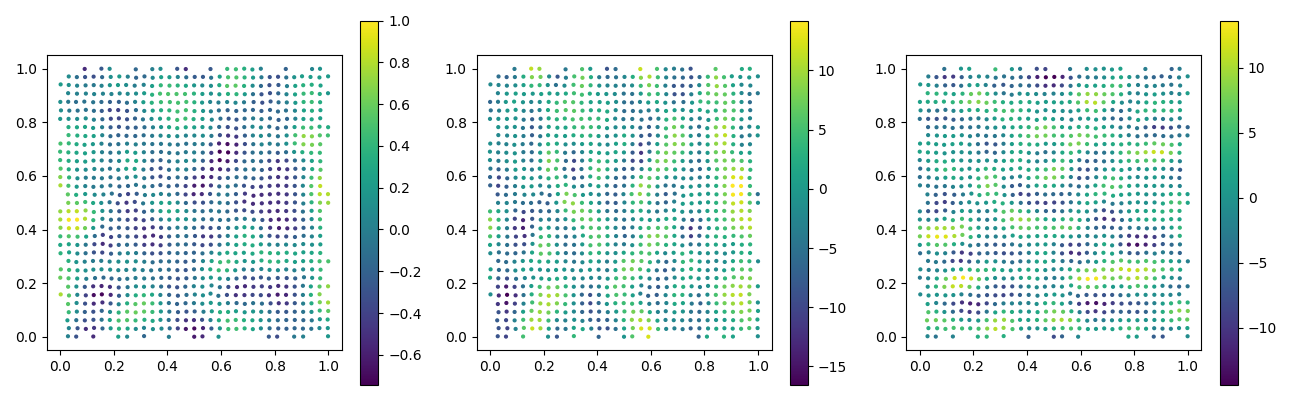

In [4]:
fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = values[0],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,  
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)


plot = visualizeParticles(fig, axis[0, 2],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.y',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)


fig.tight_layout()


In [5]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)



def prepNeighborhood(stateA, stateB, mode = SupportScheme.SuperSymmetric, verletScale = 1.0, priorNeighborhood = None):    
    mode_str = mode.name
    mode_str = mode_str[0].lower() + mode_str[1:]

    neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = verletScale, mode = mode_str, priorNeighborhood=priorNeighborhood)
    neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)


    numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
    filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
    h_i = particleState.supports[filteredNeighborhood.row].to(device)
    rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
    sparse_edge_attr = xij_ / h_i[:,None]

    # print('Maximum distance: ', (rij / h_i).max().item())

    return neighbors, filteredNeighborhood, sparse_edge_attr, numNeighbors, neighborhood

    

In [6]:
neighbors, filteredNeighborhood, sparse_edge_attr, numNeighbors, neighborhood = prepNeighborhood(particleState, particleState, mode = config['supportScheme'], verletScale = config['neighborhood']['verletScale'], priorNeighborhood = None)

Number of neighbors: torch.Size([1024]) tensor([47, 47, 48,  ..., 47, 47, 47])
torch.Size([48466])


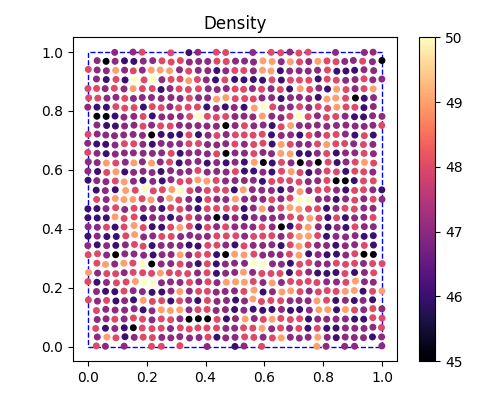

In [7]:
print('Number of neighbors:', numNeighbors.shape, numNeighbors)

fig, axis = plt.subplots(1,1 , figsize=(5,4), squeeze=False)
markerSize = 16
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Density')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()


print(neighbors.neighbors.row.shape)

In [ ]:
from layers.layer_positionEncoder import BasisEncoder
from layers.layer_mlp import MLPConfig

mlpConfig = MLPConfig(
    post_norm = True,
    norm_type = 'layer',
    hidden_dim = 32,
    hidden_layers = 2,
)

bEnc = BasisEncoder(
    verbose = True,

    spatial_dim = 2,
    base_encoding = True,
    base_function = 'pfourier',
    base_terms = 11,
    base_mode = 'cat',

    projection = True,
    projection_linear = True,
    projection_dim = 7,
    projection_bias = False,

    mlpConfig = mlpConfig,
).to(device)


encodedEdges = bEnc(sparse_edge_attr).detach()

#                       Initializing BasisEncoder Layer                        #
BasisEncoder: basis_terms=[11, 11], basis_function=['pfourier', 'pfourier'], mode=cat, spatial_dim=2
	BasisEncoder: basisShape=[22], total basis terms=22
	BasisEncoder: project_out=7, outputShape=7
BasisEncoder: basisShape=[22], total basis terms=22, outputShape=7
BasisEncoder: project_out=True, outputShape=7
BasisEncoder: projector=Linear(in_features=22, out_features=7, bias=False)
BasisEncoder Layer Initialized
#                          BasisEncoder Forward Pass                           #
	Input Positions shape: torch.Size([48466, 2]), min: -0.9999690055847168, max: 0.9999690055847168, mean: 1.869332327819606e-10, std: 0.48537880182266235
	Input Positions dim 0: min: -0.9999561309814453, max: 0.9999566078186035, mean: 4.919295526484291e-10, std: 0.48617419600486755
	Input Positions dim 1: min: -0.9999690055847168, max: 0.9999690055847168, mean: 2.4596477632421454e-11, std: 0.484587162733078
	Input Posi

In [11]:
inputFeatures = values[0]

inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
# 
gt = values[0]**2
gt = inputFeatures**2

node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))

from layers.layer_tokenEncoder import TokenEncoderConfig, TokenEncoder
from layers.layer_mixing import printTensor
import copy
encodeConfig = TokenEncoderConfig()

display(encodeConfig)
encodeConfig.projection_linear=True
encodeConfig.token_output_dim = 11

inputEncoder = TokenEncoder(1, encodeConfig, mlpConfig = mlpConfig).to(device)

encodedTokens = inputEncoder(inputFeatures.unsqueeze(0)).detach()

printTensor('encodedTokens', encodedTokens)

TokenEncoderConfig(token_input_dim=0, token_output_dim=None, token_latent_dim=None, skip_connection=True, projection=True, projection_linear=True, position_bias=None, position_bias_mixing=None, position_bias_linear=True, position_bias_dim=None, use_ffn=False, ffn_linear=False, ffn_skip_connection=False, pre_norm=False, post_norm=False, final_activation=None)

--------------------------------------------------------------------------------
Tensor encodedTokens: shape torch.Size([1, 1024, 11]), dtype torch.float32, device cpu
	min: -0.8886175751686096, max: 0.8886176943778992, mean: 4.385005468066083e-06, std: 0.4110654890537262
	Channel 0: min: -0.6988415718078613, max: 0.6988414525985718, mean: -1.7541227862238884e-05, std: 0.49435609579086304, data: 
	Channel 1: min: -0.3751078248023987, max: 0.37510785460472107, mean: 9.420327842235565e-06, std: 0.2653489410877228, data: 
	Channel 2: min: -0.5152772068977356, max: 0.5152771472930908, mean: -1.2932578101754189e-05, std: 0.3645038306713104, data: 
	Channel 3: min: -0.360901415348053, max: 0.36090147495269775, mean: 9.055016562342644e-06, std: 0.2552994191646576, data: 
	Channel 4: min: -0.6471943259239197, max: 0.6471943855285645, mean: 1.624203287065029e-05, std: 0.45782122015953064, data: 
	Channel 5: min: -0.7191381454467773, max: 0.7191380262374878, mean: -1.8042512238025665e-05, std: 0

In [12]:
token_j = encodedTokens[0,filteredNeighborhood.col]
printTensor('token_j', token_j)

--------------------------------------------------------------------------------
Tensor token_j: shape torch.Size([48466, 11]), dtype torch.float32, device cpu
	min: -0.8886175751686096, max: 0.8886176943778992, mean: -1.903205702546984e-05, std: 0.4113982617855072
	Channel 0: min: -0.6988415718078613, max: 0.6988414525985718, mean: 7.610441389260814e-05, std: 0.494541198015213, data: 
	Channel 1: min: -0.3751078248023987, max: 0.37510785460472107, mean: -4.084290412720293e-05, std: 0.26544830203056335, data: 
	Channel 2: min: -0.5152772068977356, max: 0.5152771472930908, mean: 5.610610242001712e-05, std: 0.36464032530784607, data: 
	Channel 3: min: -0.360901415348053, max: 0.36090147495269775, mean: -3.931154788006097e-05, std: 0.25539499521255493, data: 
	Channel 4: min: -0.6471943259239197, max: 0.6471943855285645, mean: -7.048272527754307e-05, std: 0.45799264311790466, data: 
	Channel 5: min: -0.7191381454467773, max: 0.7191380262374878, mean: 7.834099960746244e-05, std: 0.50890421

In [13]:
stacked = torch.cat([token_j, encodedEdges], dim=-1)
printTensor('stacked', stacked)

--------------------------------------------------------------------------------
Tensor stacked: shape torch.Size([48466, 18]), dtype torch.float32, device cpu
	min: -2.106032609939575, max: 2.082991361618042, mean: 0.021014181897044182, std: 0.4948159456253052
	Channel 0: min: -0.6988415718078613, max: 0.6988414525985718, mean: 7.610441389260814e-05, std: 0.494541198015213, data: 
	Channel 1: min: -0.3751078248023987, max: 0.37510785460472107, mean: -4.084290412720293e-05, std: 0.26544830203056335, data: 
	Channel 2: min: -0.5152772068977356, max: 0.5152771472930908, mean: 5.610610242001712e-05, std: 0.36464032530784607, data: 
	Channel 3: min: -0.360901415348053, max: 0.36090147495269775, mean: -3.931154788006097e-05, std: 0.25539499521255493, data: 
	Channel 4: min: -0.6471943259239197, max: 0.6471943855285645, mean: -7.048272527754307e-05, std: 0.45799264311790466, data: 
	Channel 5: min: -0.7191381454467773, max: 0.7191380262374878, mean: 7.834099960746244e-05, std: 0.508904218673

In [14]:
from layers.layer_mlp import MLP, MLPConfig

In [15]:
in_features = stacked.shape[-1]
out_features = 7


mlp = MLP(
    in_features = in_features,
    out_features= 16,

    seq_length = stacked.shape[0],

    hidden_norm = False,
    norm_type = 'group[4]',
    post_norm = True,

    verbose = True,
).to(device)
print(mlp)

out = mlp(stacked.unsqueeze(0))

#                               Initializing MLP                               #
MLP init kwargs: {'seq_length': 48466, 'hidden_norm': False, 'norm_type': 'group[4]', 'post_norm': True}
MLP init config: None
MLP init in_features: 18, out_features: 16
MLP Configuration: MLPConfig(input_dim=18, output_dim=16, batch_size=-1, seq_length=48466, hidden_dim=64, hidden_layers=2, activation='relu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=False, post_norm=True, hidden_norm=False, norm_type='group[4]', skip_linear=False, bias=False, residual=False)
MLP Input Dim: 18
MLP Output Dim: 16
Building MLP
Using activation: relu
No pre-norm
Using post-norm: group[4]
Building hidden layers
	Building hidden layer 1/2 with in_dim=18, out_dim=64
	Using activation: relu
	Building hidden layer 2/2 with in_dim=64, out_dim=64
	Using activation: relu
Using final linear layer with in_dim=64, out_dim=16
MLP Built
MLP Number of parameters: 6304
#                         MLP Initialization Complete     

In [16]:
latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

transformerFeatures = 5
multiHeads = 4
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = particleState.positions.shape[-1]

In [17]:
from models.common import CommonConfiguration
import copy

baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=1,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    # mlp_hidden_layers=2,
    # mlp_latent_dim = 32,
    # mlp_activation = 'silu',
)

baseConfig = copy.deepcopy(baseConfigNoEncoders)

from layers.layer_tokenEncoder import TokenEncoderConfig
encodeConfig = TokenEncoderConfig()

display(encodeConfig)
encodeConfig.projection_linear=True

decodeConfig = copy.deepcopy(encodeConfig)
decodeConfig.projection_linear=True

TokenEncoderConfig(token_input_dim=0, token_output_dim=None, token_latent_dim=None, skip_connection=True, projection=True, projection_linear=True, position_bias=None, position_bias_mixing=None, position_bias_linear=True, position_bias_dim=None, use_ffn=False, ffn_linear=False, ffn_skip_connection=False, pre_norm=False, post_norm=False, final_activation=None)

In [18]:
from models.basicTransformer import BasicTransformer
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel
from typing import Optional
import torch.nn as nn
from layers.layer_mlp import MLPConfig, MLP
from models.basicEncoder import BasicEncoder


def printTensor(name, tensor):
    print(''.join(['-']*80))
    print(f'Tensor {name}: shape {tensor.shape}, dtype {tensor.dtype}, device {tensor.device}')
    print(f'\tmin: {tensor.min().item()}, max: {tensor.max().item()}, mean: {tensor.mean().item()}, std: {tensor.std().item()}')
    # print(tensor)
    for i in range(tensor.shape[-1]):
        if len(tensor.shape) == 2:
            print(f'\tChannel {i}: min: {tensor[:,i].min().item()}, max: {tensor[:,i].max().item()}, mean: {tensor[:,i].mean().item()}, std: {tensor[:,i].std().item()}, data: ')
        else:
            print(f'\tChannel {i}: min: {tensor[:,:,i].min().item()}, max: {tensor[:,:,i].max().item()}, mean: {tensor[:,:,i].mean().item()}, std: {tensor[:,:,i].std().item()}, data: ')

    # for i in range(tensor.shape[-2]):
    #     print(f'\tParticle {i}: min: {tensor[:,i].min().item()}, max: {tensor[:,i].max().item()}, mean: {tensor[:,i].mean().item()}, std: {tensor[:,i].std().item()}, data: ')
    print(''.join(['-']*80))

class basicTest(nn.Module):
    def __init__(self, 
                 input_dim, output_dim,
                 transformer_features, multi_heads,
                 latent_dim, latent_layers,
                 encoderConfig, decoderConfig, transformerConfig, 
                 numTransformers, mlpConfig: Optional[MLPConfig] = None, mode = 'transformer'):
        super(basicTest, self).__init__()
        self.inputEncoder = BasicEncoder(
            input_dim = input_dim,
            output_dim = transformer_features * multi_heads,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            tokenEncoderConfig=encoderConfig,
                    mlpConfig= mlpConfig,
            verbose = False,
        )
        self.transformers = nn.ModuleList()
        for _ in range(numTransformers):
            if mode == 'transformer':
                transformer = BasicTransformer(
                    config = transformerConfig,
                    transformer_features = transformer_features,
                    attention_heads = multi_heads,
                    mlpConfig= mlpConfig,

                    # attention_softmax = False,

                    verbose = False,
                )
            elif mode == 'cconv':
                transformer = CConvModel(
                    config=baseConfigNoEncoders,
                    mlpConfig= mlpConfig,

                    verbose = False,
                )
            elif mode == 'gnn':
                transformer = GNNModel(
                    config = baseConfigNoEncoders,
                    mlpConfig= mlpConfig,

                    use_edge_mlp=True,
                    use_edge_encoder = True,
                    inputEdgeEncoderTokenConfig = None,
                    verbose = True,
                )
            self.transformers.append(transformer)
        self.decoder = BasicEncoder(
            input_dim = transformer_features * multi_heads,
            output_dim = output_dim,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            tokenEncoderConfig=decoderConfig,
                    mlpConfig= mlpConfig,
            verbose = True,
        )

    def forward(self, node_attr, edge_attr, edge_index, node_positions):
        # print('Input node_attr shape:', node_attr.shape)
        printTensor('node_attr', node_attr)
        x = self.inputEncoder(node_attr, inputPositions = node_positions)
        # print('Encoded input shape:', x.shape)
        printTensor('encoded node_attr', x)
        for i, transformer in enumerate(self.transformers):
            x = transformer(
                node_features = x,
                node_positions = node_positions[0],
                edge_indices = edge_index,
                edge_features = None,
                edge_spatial_features = edge_attr)
            printTensor(f'after transformer {i}', x)
            # print('Transformed shape:', x.shape)
        out = self.decoder(x, inputPositions = node_positions)
        # print('Output shape:', out.shape)
        printTensor('output', out)
        return out
    
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

multiHeads = 1
transformerFeatures = 11



baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=1,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    # mlp_hidden_layers=3,
    # mlp_latent_dim = 32,
    # mlp_activation = 'sigmoid',
)

mlpConfig = MLPConfig(
    post_norm = True,
    norm_type = 'layer',
    hidden_dim = 32,
    hidden_layers = 2,
)

basicModel = basicTest(
    input_dim = inputFeatures.shape[-1],
    output_dim = gt.shape[-1],
    transformer_features = transformerFeatures,
    multi_heads = multiHeads,
    latent_dim = 32,
    latent_layers = 1,
    encoderConfig = encodeConfig,
    decoderConfig = decodeConfig,
    transformerConfig = baseConfigNoEncoders,
    numTransformers = 1,
    mlpConfig = mlpConfig,
    mode = 'gnn'
).to(device)

Initializing GNN Model...
	GNN config: CommonConfiguration(token_input_dim=11, token_output_dim=11, spatial_dim=2, edge_feature_dim=0, latent_features=11, hidden_layers=1, use_encoder=False, use_decoder=False, inputEncoderTokenConfig=None, outputDecoderTokenConfig=None, node_ffn=True, ffn_skip_connection=False, ffn_skip_projection=False, post_ffn_norm=None, ffn_skip_last=False, message_skip_connections=True, message_skip_projection=False, post_message_norm=None, message_activation=None, basis_function='ffourier', basis_terms=6, basis_projection='cartesian', basis_mode='cat')
	Adding input edge encoder.
#                   EdgeEnc|Initializing BasisEncoder Layer                    #
EdgeEnc|BasisEncoder: basis_terms=[6, 6], basis_function=['ffourier', 'ffourier'], mode=cat, spatial_dim=2
EdgeEnc|	BasisEncoder: basisShape=[12], total basis terms=12
EdgeEnc|	BasisEncoder: project_out=11, outputShape=11
EdgeEnc|BasisEncoder: basisShape=[12], total basis terms=12, outputShape=11
EdgeEnc|Bas

In [19]:
from layers.layer_positionEncoder import BasisEncoder
bEnc = BasisEncoder(
    verbose = True,

    spatial_dim = 2,
    base_encoding = True,
    base_function = 'pfourier',
    base_terms = 11,
    base_mode = 'cat',

    projection = True,
    projection_linear = False,
    projection_dim = 7,
    projection_bias = False,
    mlpConfig = mlpConfig,
).to(device)





encodedEdges = bEnc(sparse_edge_attr).detach()

#                       Initializing BasisEncoder Layer                        #
BasisEncoder: basis_terms=[11, 11], basis_function=['pfourier', 'pfourier'], mode=cat, spatial_dim=2
	BasisEncoder: basisShape=[22], total basis terms=22
	BasisEncoder: project_out=7, outputShape=7
BasisEncoder: basisShape=[22], total basis terms=22, outputShape=7
BasisEncoder: project_out=True, outputShape=7
#                              	Initializing MLP                               #
	MLP init kwargs: {}
	MLP init config: MLPConfig(input_dim=-1, output_dim=-1, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='relu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=False, post_norm=True, hidden_norm=False, norm_type='layer', skip_linear=False, bias=False, residual=False)
	MLP init in_features: 22, out_features: 7
	MLP Configuration: MLPConfig(input_dim=22, output_dim=7, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='relu', initializer='uniform', 

In [24]:
inputFeatures = values[0]

inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
# 
gt = values[0]**2
gt = inputFeatures**2
# gt = values[1][:,0].view(-1,1)
# gt = torch.cos(particleState.positions[:,0].view(-1,1)*2*np.pi) * 2

# gt = 2 * particleState.positions[:,0].view(-1,1)

print(f'Input features: {inputFeatures.shape}, GT: {gt.shape}')
print(f'Input features statistics: max: {inputFeatures.max()}, min: {inputFeatures.min()}, mean: {inputFeatures.mean()}, std: {inputFeatures.std()}')
print(f'GT statistics: max: {gt.max()}, min: {gt.min()}, mean: {gt.mean()}, std: {gt.std()}')


neighbors, filteredNeighborhood, sparse_edge_attr, numNeighbors, neighborhood = prepNeighborhood(particleState, particleState, mode = config['supportScheme'], verletScale = config['neighborhood']['verletScale'], priorNeighborhood = None)

edge_attr = sparse_edge_attr
node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))
edge_indices = torch.stack([filteredNeighborhood.row, filteredNeighborhood.col], dim=0)
node_positions = (particleState.positions.unsqueeze(0), particleState.positions.unsqueeze(0))


print(edge_indices.shape)

basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0)


Input features: torch.Size([1024, 1]), GT: torch.Size([1024, 1])
Input features statistics: max: 1.0, min: -1.0, mean: -0.00026179198175668716, std: 0.7074174880981445
GT statistics: max: 1.0, min: 5.388909318781998e-10, mean: 0.4999508261680603, std: 0.35372424125671387
torch.Size([2, 48464])
--------------------------------------------------------------------------------
Tensor node_attr: shape torch.Size([1, 1024, 1]), dtype torch.float32, device cpu
	min: -1.0, max: 1.0, mean: -0.00026179198175668716, std: 0.7074174880981445
	Channel 0: min: -1.0, max: 1.0, mean: -0.00026179198175668716, std: 0.7074174880981445, data: 
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Tensor encoded node_attr: shape torch.Size([1, 1024, 11]), dtype torch.float32, device cpu
	min: -0.9951450824737549, max: 0.9951450824737549, mean: 1.3693278560822364e-05, std: 0.45483770966529846
	Channel 

In [ ]:
from layers.mlp import buildMLPwDict, getDefaultMLPDict

ratios = []
mlpDict = getDefaultMLPDict()
mlpDict['activation'] = 'relu'
mlpDict['layout'] = [128,128]
mlpDict['norm'] = True
# mlpDict['gain'] = 2.908

ratio2s = []

for i in range(2**8):
    mlp = buildMLPwDict(mlpDict, inputDim = in_features, outputDim = out_features)

    proj = mlp(stacked).detach()
    ratios.append(proj.std().item())
    ratio2s.append(proj.std(dim=0).numpy())

    # print(f'Projection {i} std:', proj.std(dim =0))

ratios = np.array(ratios)
ratio2s = np.array(ratio2s)

# print('Std ratios of random projections:', ratios)
print('Std ratios per channel: \n mean:', ratio2s.mean(axis=0), '\n std:', ratio2s.std(axis=0))

meanStd = np.mean(ratios)
print('Mean std of random projections:', meanStd)

print('stacked edges std:', stacked.std().item())

ratio = stacked.std().item() / meanStd
print('Scaling ratio:', ratio)

ratioPerChannel = stacked.std().numpy() / ratio2s.mean(axis=0)
print('Scaling ratio per channel:', ratioPerChannel)

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)